#Skin Cancer Classification and Segmentation🎗️

##Import Libraries and Dataset

In [2]:
#!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.9/960.9 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 755.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninst

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import kagglehub
import torchvision.transforms.functional as F
import random
from sklearn.utils.class_weight import compute_class_weight
from torchmetrics.detection import IntersectionOverUnion
from torchmetrics.segmentation import DiceScore

path = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2


##Load CSV File and Print Head

In [2]:
# Load CSV File
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(df.head())
df.dropna(inplace=True)  # Drop missing values if any



          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0


##Define Image and Mask Paths and Remove Corrupt Data


In [3]:
image_dir = os.path.join(path, "images")
mask_dir = os.path.join(path, "masks")
class_names = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

# Convert one-hot encoding to integer labels
df["label"] = df[class_names].idxmax(axis=1).map(lambda x: class_names.index(x))


# Create lists of image paths and labels
images = df["image"].apply(lambda x: os.path.join(image_dir, x + ".jpg")).tolist()
masks = df["image"].apply(lambda x: os.path.join(mask_dir, x + "_segmentation.png")).tolist()
labels = df["label"].tolist()  # Now correctly using integer class labels

for i in range(5):
  print(f"Example Image Path {i}: {images[i]}")
  print(f"Example Mask Path {i}: {masks[i]}")
  print(f"Example Label {i}: {labels[i]}")


valid_samples = []
for img, mask in zip(images, masks):
    try:
        if os.path.exists(img) and os.path.exists(mask):
            Image.open(img).verify()
            Image.open(mask).verify()
            valid_samples.append((img, mask))
    except:
        print(f"Corrupt file detected: {img} or {mask}")

images, masks = zip(*valid_samples) if valid_samples else ([], [])
labels = [labels[i] for i in range(len(valid_samples))] if valid_samples else []



Example Image Path 0: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/images/ISIC_0024306.jpg
Example Mask Path 0: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/masks/ISIC_0024306_segmentation.png
Example Label 0: 1
Example Image Path 1: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/images/ISIC_0024307.jpg
Example Mask Path 1: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/masks/ISIC_0024307_segmentation.png
Example Label 1: 1
Example Image Path 2: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/images/ISIC_0024308.jpg
Example Mask Path 2: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/masks/ISIC_0024308_segmentation.png
Example Label 2: 1
Example Image Path 3: /root/.cache

##Split Data

In [4]:
# Time to Split
train_imgs, temp_imgs, train_labels, temp_labels, train_masks, temp_masks = train_test_split(
    images, labels, masks, test_size=0.3, random_state=42, stratify=labels
)
val_imgs, test_imgs, val_labels, test_labels, val_masks, test_masks = train_test_split(
    temp_imgs, temp_labels, temp_masks, test_size=0.5, random_state=42, stratify=temp_labels
)
# Print dataset sizes
print(f"Dataset size: {len(df)}")
print(f"Training size: {len(train_imgs)}")
print(f"Validation size: {len(val_imgs)}")
print(f"Test size: {len(test_imgs)}")


Dataset size: 10015
Training size: 7010
Validation size: 1502
Test size: 1503


##Count number of Occurence of Each Label


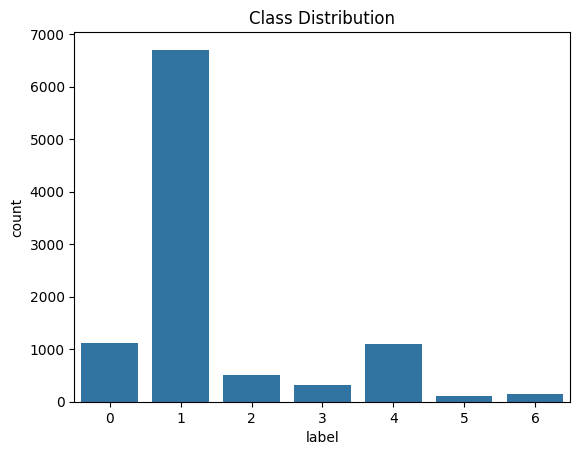

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df["label"])
plt.title("Class Distribution")
plt.show()


In [7]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Convert train_masks to a NumPy array
train_masks = np.array(train_masks)

# Calculate class weights
class_weights_segmentation = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_masks),  # Unique classes in the segmentation masks
    y=train_masks.flatten()  # Flatten the masks to get a 1D array of labels
)

# Convert to a tensor and move to the correct device
class_weights_segmentation = torch.tensor(class_weights_segmentation, dtype=torch.float32).to(device)

print("Class Weights:", class_weights_segmentation)

Class Weights: tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0')


In [8]:
# Calculate class weights
class_weights_classification = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["label"]),  # Unique classes: [0, 1, 2]
    y=df["label"]  # Labels: [0, 1, 2, 0, 1, 2, 0, 1, 2]
)

# Convert to a tensor
class_weights_classification = torch.tensor(class_weights_classification, dtype=torch.float32).to(device)
print(class_weights_classification)

tensor([ 1.2855,  0.2134,  2.7835,  4.3753,  1.3018, 12.4410, 10.0755],
       device='cuda:0')


##Define Data Transformation

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # Flip images randomly
    transforms.RandomRotation(10),  # Rotate images randomly
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


##Create Dataset Class

In [10]:
class SkinDataset(Dataset):
    def __init__(self, image_paths, mask_paths, labels, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")  # Grayscale mask

        # Resize both image and mask
        img = F.resize(img, (224, 224))
        mask = F.resize(mask, (224, 224), interpolation=Image.NEAREST)  # Nearest for segmentation masks

        # Apply the same random transformation to both
        if random.random() > 0.5:
            img = F.hflip(img)
            mask = F.hflip(mask)

        img = F.to_tensor(img)
        mask = F.to_tensor(mask)

        return img, mask, torch.tensor(self.labels[idx], dtype=torch.long)


# Create datasets
# Create datasets with masks included
train_dataset = SkinDataset(train_imgs, train_masks, train_labels, transform=train_transform)
val_dataset = SkinDataset(val_imgs, val_masks, val_labels, transform=val_test_transform)
test_dataset = SkinDataset(test_imgs, test_masks, test_labels, transform=val_test_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



##Visualize Sample Images

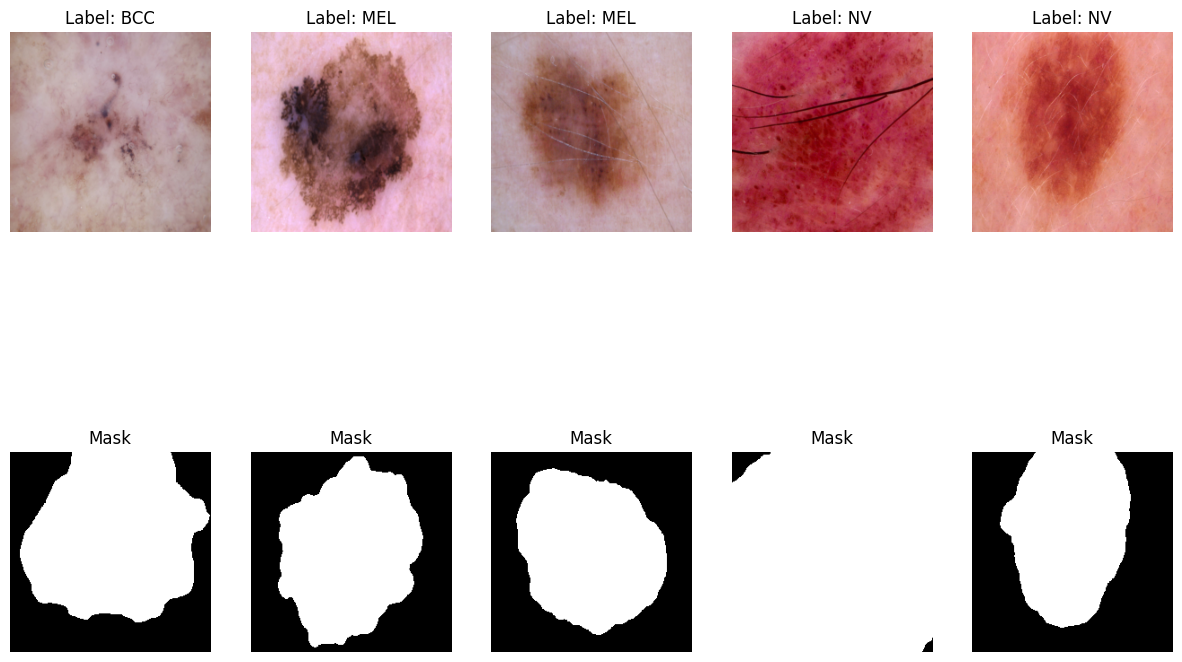

In [11]:
# Function to visualize images with their corresponding masks
def show_sample(dataset, num_samples=5):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 10))

    for i in range(num_samples):
        img, mask, label = dataset[i]  # Unpack correctly
        img = img.permute(1, 2, 0).numpy()  # Convert (3, 224, 224) -> (224, 224, 3)
        mask = mask.squeeze(0).numpy()  # Convert (1, 224, 224) -> (224, 224)

        # Show image
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Label: {class_names[label]}")
        axes[0, i].axis("off")

        # Show corresponding mask
        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].set_title("Mask")
        axes[1, i].axis("off")

    plt.show()

# Show train samples
show_sample(train_dataset)


In [12]:
import torch
import torch.nn as nn
import torchvision.models as models

# pretrained ResNet18
resnet18 = models.resnet18(pretrained=True)

for param in resnet18.parameters():
    param.requires_grad = False  # Freeze all layers
for param in resnet18.layer4.parameters():
    param.requires_grad = True

num_classes = 7  # elskin cancer classed
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18 = resnet18.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet18.parameters()), lr=1e-4)

# Training
for epoch in range(10):
    resnet18.train()
    running_loss = 0.0

    for images, masks, labels in train_loader:  # images and labels for classification
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet18(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/10] Loss: {running_loss/len(train_loader):.4f}")

print("Training Done ??")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10] Loss: 0.6903
Epoch [2/10] Loss: 0.3884
Epoch [3/10] Loss: 0.2652
Epoch [4/10] Loss: 0.1746
Epoch [5/10] Loss: 0.1211
Epoch [6/10] Loss: 0.0887
Epoch [7/10] Loss: 0.0577
Epoch [8/10] Loss: 0.0555
Epoch [9/10] Loss: 0.0592
Epoch [10/10] Loss: 0.0297
Training Done ??


In [13]:
total_params = sum(p.numel() for p in resnet18.parameters())
print(f"Total Parameters: {total_params:,}")


Total Parameters: 11,180,103


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
#import torch.nn.functional as F

resnet18.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, _, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = resnet18(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [15]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {accuracy*100:.2f}%")


Test Accuracy: 83.83%


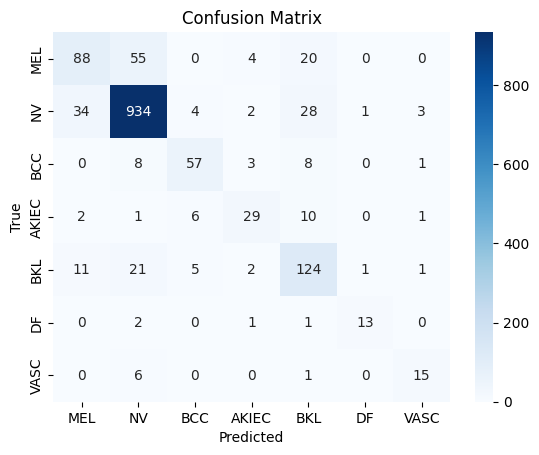

In [16]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [17]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

         MEL       0.65      0.53      0.58       167
          NV       0.91      0.93      0.92      1006
         BCC       0.79      0.74      0.77        77
       AKIEC       0.71      0.59      0.64        49
         BKL       0.65      0.75      0.69       165
          DF       0.87      0.76      0.81        17
        VASC       0.71      0.68      0.70        22

    accuracy                           0.84      1503
   macro avg       0.76      0.71      0.73      1503
weighted avg       0.84      0.84      0.84      1503



In [18]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=7):  # 7 classes for segmentation
        super(UNet, self).__init__()

        # Encoder (Downsampling)
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)

        # Decoder (Upsampling)
        self.upconv4 = self.upconv(1024, 512)
        self.dec4 = self.conv_block(1024, 512)

        self.upconv3 = self.upconv(512, 256)
        self.dec3 = self.conv_block(512, 256)

        self.upconv2 = self.upconv(256, 128)
        self.dec2 = self.conv_block(256, 128)

        self.upconv1 = self.upconv(128, 64)
        self.dec1 = self.conv_block(128, 64)

        # Final Convolution
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def upconv(self, in_ch, out_ch):
        return nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(nn.MaxPool2d(2)(e1))
        e3 = self.enc3(nn.MaxPool2d(2)(e2))
        e4 = self.enc4(nn.MaxPool2d(2)(e3))

        # Bottleneck
        b = self.bottleneck(nn.MaxPool2d(2)(e4))

        # Decoder
        d4 = self.upconv4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)  # Output shape: (batch, 7, H, W)

In [ ]:
# Initialize Model

# Initialize model, loss, and optimizer
model = UNet(in_channels=3, out_channels=7).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3)

# Training loop
num_epochs = 10
best_val_loss = float("inf")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, masks, labels in train_loader:
        images, masks = images.to(device), masks.to(device)
        masks = masks.squeeze(1)  # Remove singleton dimension

        # Forward pass
        preds = model(images)
        loss = criterion(preds, masks.long())

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Validation loop
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks, labels in val_loader:
            images, masks = images.to(device), masks.to(device)
            masks = masks.squeeze(1)
            preds = model(images)
            loss = criterion(preds, masks.long())
            val_loss += loss.item()

    # Adjust learning rate
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_unet.pth")

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_loss:.4f}, Validation Loss: {val_loss:.4f}")

Epoch 1/20, Training Loss: 83.7266, Validation Loss: 13.2911
Epoch 2/20, Training Loss: 41.4219, Validation Loss: 8.5543
Epoch 3/20, Training Loss: 35.0613, Validation Loss: 7.2501
Epoch 4/20, Training Loss: 33.6456, Validation Loss: 6.6436
Epoch 5/20, Training Loss: 31.7009, Validation Loss: 6.8654
Epoch 6/20, Training Loss: 29.8972, Validation Loss: 6.0261
Epoch 7/20, Training Loss: 29.4364, Validation Loss: 6.1209
Epoch 8/20, Training Loss: 28.3877, Validation Loss: 6.0276
Epoch 9/20, Training Loss: 28.9561, Validation Loss: 5.6195
Epoch 10/20, Training Loss: 27.3779, Validation Loss: 5.5684
Epoch 11/20, Training Loss: 26.7682, Validation Loss: 5.6895
Epoch 12/20, Training Loss: 25.9959, Validation Loss: 5.1845


In [1]:
model.load_state_dict(torch.load("best_unet.pth"))  # Load the best model weights
model.eval()  # Set the model to evaluation mode

NameError: name 'model' is not defined

In [ ]:
# Initialize metrics
iou = IntersectionOverUnion(num_classes=7).to(device)  # 7 classes for segmentation
dice = DiceScore(num_classes=7).to(device)  # 7 classes for segmentation

In [ ]:
with torch.no_grad():  # Disable gradient computation
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        masks = masks.squeeze(1)  # Remove singleton dimension if necessary

        # Forward pass
        preds = model(images)  # Shape: (batch_size, 7, H, W)

        # Update metrics
        iou.update(preds.argmax(dim=1), masks)  # preds.argmax(dim=1) gives the predicted class indices
        dice.update(preds.argmax(dim=1), masks)

In [ ]:
# Compute metrics
test_iou = iou.compute()
test_dice = dice.compute()

print(f"Test IoU: {test_iou:.4f}")
print(f"Test Dice: {test_dice:.4f}")

In [ ]:
import matplotlib.pyplot as plt

def plot_results(image, true_mask, pred_mask):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(image.permute(1, 2, 0).cpu())
    plt.title("Image")
    plt.subplot(1, 3, 2)
    plt.imshow(true_mask.cpu(), cmap="gray")
    plt.title("True Mask")
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask.argmax(dim=0).cpu(), cmap="gray")
    plt.title("Predicted Mask")
    plt.show()

# Visualize a few test samples
for images, masks, labels in test_loader:
    images, masks = images.to(device), masks.to(device)
    masks = masks.squeeze(1)
    preds = model(images)
    for i in range(min(3, len(images))):  # Visualize first 3 samples
        plot_results(images[i], masks[i], preds[i])
    break  # Stop after visualizing one batch